In [5]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy.stats
import math
import time

In [6]:
a = 4990
b = 5010
n = 1000
wav = []
for i in range(n):
    x = a + i*((b-a)/(n-1))
    wav.append(x)
print(wav)

wav0 = 5000.0
sigma  = 1.0
Amp = 1.0


[4990.0, 4990.02002002002, 4990.04004004004, 4990.06006006006, 4990.08008008008, 4990.1001001001005, 4990.12012012012, 4990.14014014014, 4990.160160160161, 4990.18018018018, 4990.2002002002, 4990.220220220221, 4990.24024024024, 4990.26026026026, 4990.28028028028, 4990.3003003003005, 4990.32032032032, 4990.34034034034, 4990.360360360361, 4990.38038038038, 4990.4004004004, 4990.420420420421, 4990.44044044044, 4990.46046046046, 4990.480480480481, 4990.5005005005005, 4990.52052052052, 4990.540540540541, 4990.560560560561, 4990.58058058058, 4990.600600600601, 4990.620620620621, 4990.64064064064, 4990.660660660661, 4990.680680680681, 4990.7007007007005, 4990.720720720721, 4990.740740740741, 4990.760760760761, 4990.78078078078, 4990.800800800801, 4990.820820820821, 4990.84084084084, 4990.860860860861, 4990.880880880881, 4990.9009009009005, 4990.920920920921, 4990.940940940941, 4990.960960960961, 4990.980980980981, 4991.001001001001, 4991.021021021021, 4991.041041041041, 4991.061061061061, 499

$$Flux = 1 -depth *exp[-1/2 ((wav-wav0)/sigma)^2]$$

version 1 with math.exp


In [7]:
def gaussian_loop(wav,wav0,sigma,Amp):
    result = []
    for wav_i in wav:
        x = Amp*math.exp(-(wav_i-wav0)**2/(2*sigma**2))
        result.append(x)
    return np.array(result)

profile1 = gaussian_loop(wav,wav0,sigma,Amp)
print(profile1)
N_runs = 10000

t0 = time.time()
for _ in range(N_runs):
    gaussian_loop(wav,wav0,sigma,Amp)
t_loop1 = (time.time() - t0) / N_runs
print(t_loop1)

[1.92874985e-22 2.35577991e-22 2.87620249e-22 3.51018605e-22
 4.28219803e-22 5.22190894e-22 6.36528384e-22 7.75589980e-22
 9.44653501e-22 1.15010852e-21 1.39968736e-21 1.70274334e-21
 2.07058602e-21 2.51688457e-21 3.05815330e-21 3.71433560e-21
 4.50950595e-21 5.47271361e-21 6.63899610e-21 8.05059611e-21
 9.75842209e-21 1.18238005e-20 1.43205772e-20 1.73376362e-20
 2.09819178e-20 2.53820335e-20 3.06925929e-20 3.70993823e-20
 4.48255589e-20 5.41390563e-20 6.53614358e-20 7.88784596e-20
 9.51527166e-20 1.14738693e-19 1.38300750e-19 1.66634572e-19
 2.00692720e-19 2.41615094e-19 2.90765207e-19 3.49773376e-19
 4.20588112e-19 5.05537263e-19 6.07400698e-19 7.29496705e-19
 8.75784625e-19 1.05098673e-18 1.26073289e-18 1.51173222e-18
 1.81197661e-18 2.17098209e-18 2.60007472e-18 3.11272927e-18
 3.72497023e-18 4.45584624e-18 5.32799147e-18 6.36828923e-18
 7.60865641e-18 9.08697013e-18 1.08481620e-17 1.29455098e-17
 1.54421614e-17 1.84129321e-17 2.19464233e-17 2.61475188e-17
 3.11403257e-17 3.707163

$$flux(wav) = Amp*math.exp(-(wav_i-wav0)^2/(2*sigma^2))$$

Gaussian spectral line model

version 2 with np.exp

In [8]:
wav = np.linspace(4990,5010,1000)
print(type(wav))
def gaussian_num(wav,wav0,sigma,Amp):
    y = (wav-wav0)**2
    result = Amp*np.exp(-y/(2*sigma**2))
    return np.array(result)

profile2 = gaussian_num(wav,wav0,sigma,Amp)
print(profile2)
N_runs = 10000

t0 = time.time()
for _ in range(N_runs):
    gaussian_num(wav,wav0,sigma,Amp)
t_loop2 = (time.time() - t0) / N_runs
print(t_loop2)

<class 'numpy.ndarray'>
[1.92874985e-22 2.35577991e-22 2.87620249e-22 3.51018605e-22
 4.28219803e-22 5.22190894e-22 6.36528384e-22 7.75589980e-22
 9.44653501e-22 1.15010852e-21 1.39968736e-21 1.70274334e-21
 2.07058602e-21 2.51688457e-21 3.05815330e-21 3.71433560e-21
 4.50950595e-21 5.47271361e-21 6.63899610e-21 8.05059611e-21
 9.75842209e-21 1.18238005e-20 1.43205772e-20 1.73376362e-20
 2.09819178e-20 2.53820335e-20 3.06925929e-20 3.70993823e-20
 4.48255589e-20 5.41390563e-20 6.53614358e-20 7.88784596e-20
 9.51527166e-20 1.14738693e-19 1.38300750e-19 1.66634572e-19
 2.00692720e-19 2.41615094e-19 2.90765207e-19 3.49773376e-19
 4.20588112e-19 5.05537263e-19 6.07400698e-19 7.29496705e-19
 8.75784625e-19 1.05098673e-18 1.26073289e-18 1.51173222e-18
 1.81197661e-18 2.17098209e-18 2.60007472e-18 3.11272927e-18
 3.72497023e-18 4.45584624e-18 5.32799147e-18 6.36828923e-18
 7.60865641e-18 9.08697013e-18 1.08481620e-17 1.29455098e-17
 1.54421614e-17 1.84129321e-17 2.19464233e-17 2.61475188e-17


version 3 with scipy


In [9]:
def gaussian_scipy(wav,wav0,sigma):
    result = scipy.stats.norm.pdf(wav,wav0,sigma) * sigma*np.sqrt(2*np.pi)
    return result

profile3 = gaussian_scipy(wav,wav0,sigma)
print(profile3)

N_runs = 10000

t0 = time.time()
for _ in range(N_runs):
    gaussian_scipy(wav,wav0,sigma)
t_loop3 = (time.time() - t0) / N_runs
print(t_loop3)

# repeat for numpy and scipy versions

[1.92874985e-22 2.35577991e-22 2.87620249e-22 3.51018605e-22
 4.28219803e-22 5.22190894e-22 6.36528384e-22 7.75589980e-22
 9.44653501e-22 1.15010852e-21 1.39968736e-21 1.70274334e-21
 2.07058602e-21 2.51688457e-21 3.05815330e-21 3.71433560e-21
 4.50950595e-21 5.47271361e-21 6.63899610e-21 8.05059611e-21
 9.75842209e-21 1.18238005e-20 1.43205772e-20 1.73376362e-20
 2.09819178e-20 2.53820335e-20 3.06925929e-20 3.70993823e-20
 4.48255589e-20 5.41390563e-20 6.53614358e-20 7.88784596e-20
 9.51527166e-20 1.14738693e-19 1.38300750e-19 1.66634572e-19
 2.00692720e-19 2.41615094e-19 2.90765207e-19 3.49773376e-19
 4.20588112e-19 5.05537263e-19 6.07400698e-19 7.29496705e-19
 8.75784625e-19 1.05098673e-18 1.26073289e-18 1.51173222e-18
 1.81197661e-18 2.17098209e-18 2.60007472e-18 3.11272927e-18
 3.72497023e-18 4.45584624e-18 5.32799147e-18 6.36828923e-18
 7.60865641e-18 9.08697013e-18 1.08481620e-17 1.29455098e-17
 1.54421614e-17 1.84129321e-17 2.19464233e-17 2.61475188e-17
 3.11403257e-17 3.707163

In [10]:
np.allclose(profile1,profile2,atol = 1e-15,rtol=0)
np.allclose(profile2,profile3,atol = 1e-15,rtol=0)

True

all three give the same result of the gaussian spctral model with rtol being zero they are true till atol is 1e-15  at 1e-16 they are false

In [11]:
print("loop = ",t_loop1,"numpy = ",t_loop2,"scipy = ",t_loop3)

loop =  0.0008984975576400757 numpy =  5.6196093559265135e-05 scipy =  0.00035070548057556153


(1000,) (1000,)


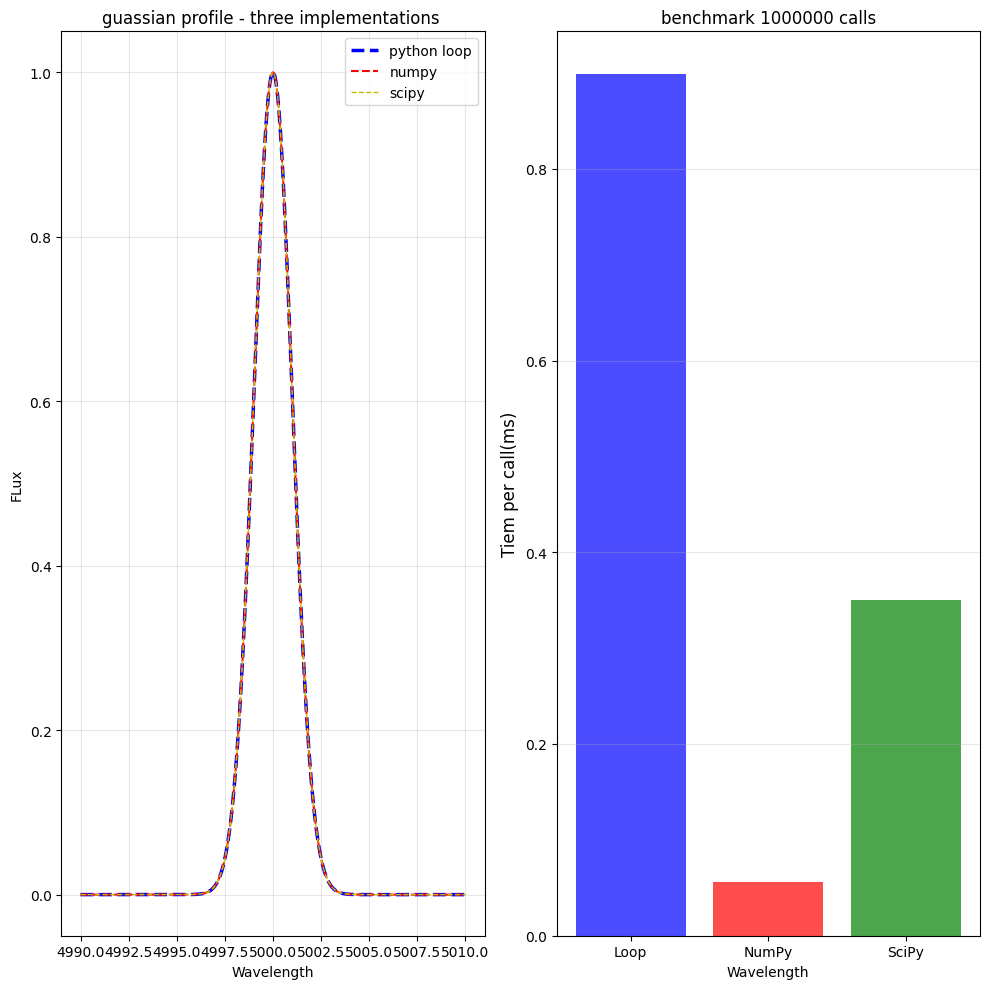

saved


In [12]:
fig,axes = plt.subplots(1,2,figsize=(10,10))
print(wav.shape,profile1.shape)
ax = axes[0]
ax.plot(wav,profile1,'b--',linewidth = 2.5,label = 'python loop')
ax.plot(wav,profile2,'r--',linewidth = 1.5,label = 'numpy')
ax.plot(wav,profile3,'y--',linewidth = 1,label = 'scipy')
ax.set_xlabel('Wavelength')
ax.set_ylabel('FLux')
ax.set_title('guassian profile - three implementations ')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)


ax2 = axes[1]
labels = ['Loop', 'NumPy', 'SciPy']
times  = [t_loop1*1000, t_loop2*1000, t_loop3*1000]   # convert to ms
ax2.bar(labels, times, color=['blue', 'red', 'green'], alpha=0.7)
ax2.set_xlabel('Wavelength')
ax2.set_ylabel('Tiem per call(ms)',fontsize = 12)
ax2.set_title('benchmark 1000000 calls',fontsize = 12)
ax2.grid(alpha=0.3, axis='y')
        
plt.tight_layout()
plt.savefig('C:/Users/chand/OneDrive/Desktop/RV/rv-pipeline/day01_guassian_bechmark.png',dpi= 200,bbox_inches = 'tight')
plt.show()
print("saved")